<a href="https://colab.research.google.com/github/Prakruthi2606/HR-Attrition-Prediction/blob/main/HR_Attrition_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **HR Attrition Prediction (Classification)**

### Problem statement

Employee attrition is a critical issue for organizations, leading to increased hiring costs,
productivity loss, and reduced employee morale.<br>
In this project, the goal is to build a Machine Learning classification model that predicts
whether an employee will leave the company (Attrition: Yes/No) based on features such as:
* Age
* Salary
* Job Role
* Job Satisfaction
* Work Experience
* Overtime
* Work-Life Balance
* Department

### Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### Load Data

In [ ]:
df = pd.read_csv('HR-Employee-Attrition.csv')
df

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8


### Basic Checks

In [ ]:
# shape : gives number of rows and columns
df.shape

(1470, 35)

In [ ]:
# print all columns
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [ ]:
# check the data type
df.dtypes

,0
Age,int64
Attrition,object
BusinessTravel,object
DailyRate,int64
Department,object
DistanceFromHome,int64
Education,int64
EducationField,object
EmployeeCount,int64
EmployeeNumber,int64


In [ ]:
# statiscal report for numerical column
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [ ]:
# statiscal report for categorical column
df.describe(include='object')

,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,Over18,OverTime
count,1470,1470,1470,1470,1470,1470,1470,1470,1470
unique,2,3,3,6,2,9,3,1,2
top,No,Travel_Rarely,Research & Development,Life Sciences,Male,Sales Executive,Married,Y,No
freq,1233,1043,961,606,882,326,673,1470,1054


In [ ]:
# find unique values in categorical column
cat_col= df.select_dtypes(include=['object'])
for x in cat_col:
  print(x,'-->',df[x].unique())

Attrition --> ['Yes' 'No']
BusinessTravel --> ['Travel_Rarely' 'Travel_Frequently' 'Non-Travel']
Department --> ['Sales' 'Research & Development' 'Human Resources']
EducationField --> ['Life Sciences' 'Other' 'Medical' 'Marketing' 'Technical Degree'
 'Human Resources']
Gender --> ['Female' 'Male']
JobRole --> ['Sales Executive' 'Research Scientist' 'Laboratory Technician'
 'Manufacturing Director' 'Healthcare Representative' 'Manager'
 'Sales Representative' 'Research Director' 'Human Resources']
MaritalStatus --> ['Single' 'Married' 'Divorced']
Over18 --> ['Y']
OverTime --> ['Yes' 'No']


In [ ]:
# find value counts
for x in cat_col:
  print(df[x].value_counts())
  print()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

BusinessTravel
Travel_Rarely        1043
Travel_Frequently     277
Non-Travel            150
Name: count, dtype: int64

Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64

EducationField
Life Sciences       606
Medical             464
Marketing           159
Technical Degree    132
Other                82
Human Resources      27
Name: count, dtype: int64

Gender
Male      882
Female    588
Name: count, dtype: int64

JobRole
Sales Executive              326
Research Scientist           292
Laboratory Technician        259
Manufacturing Director       145
Healthcare Representative    131
Manager                      102
Sales Representative          83
Research Director             80
Human Resources               52
Name: count, dtype: int64

MaritalStatus
Married     673
Single      470
Divorced    327
Name: count, dtype: int64

Over18
Y    1470
Name:

### Handling missing values

In [ ]:
#check for missing values
df.isnull().sum()


,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


### Removing duplicate records

In [ ]:
#check for duplicates
df.duplicated().sum()

np.int64(0)

### Exploratory Data Analysis (EDA)


1. Univariate Analysis

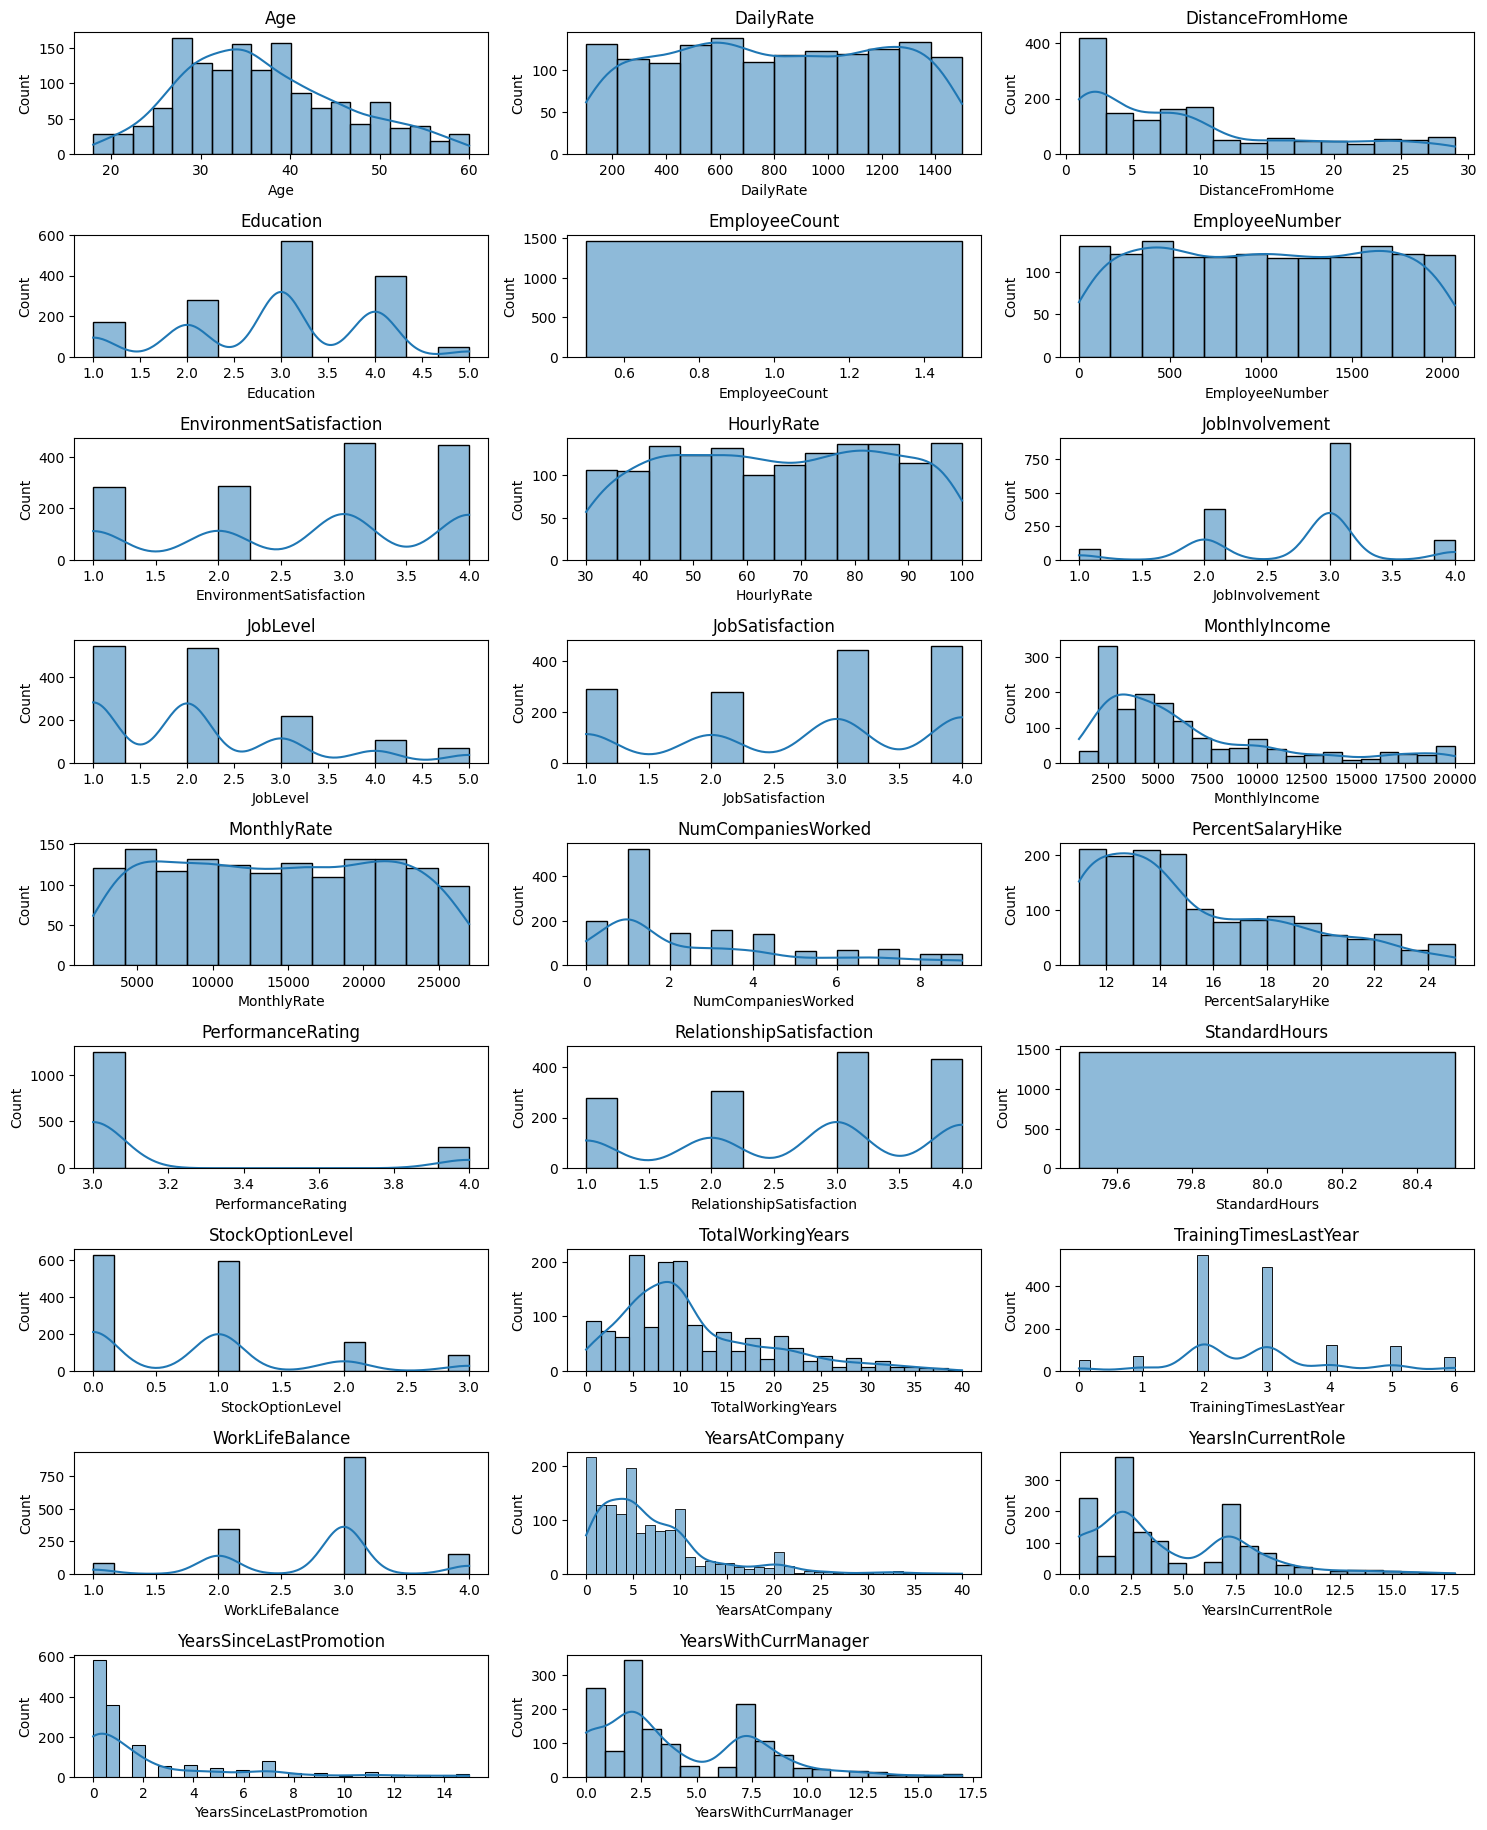

In [ ]:
# Distribution of numerical features (Histogram)
num_cols = df.select_dtypes(include=['int64','float64']).columns

plt.figure(figsize=(15, 20))

for i, col in enumerate(num_cols, 1):
    plt.subplot(10, 3, i)   # adjust rows, cols based on count
    sns.histplot(df[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

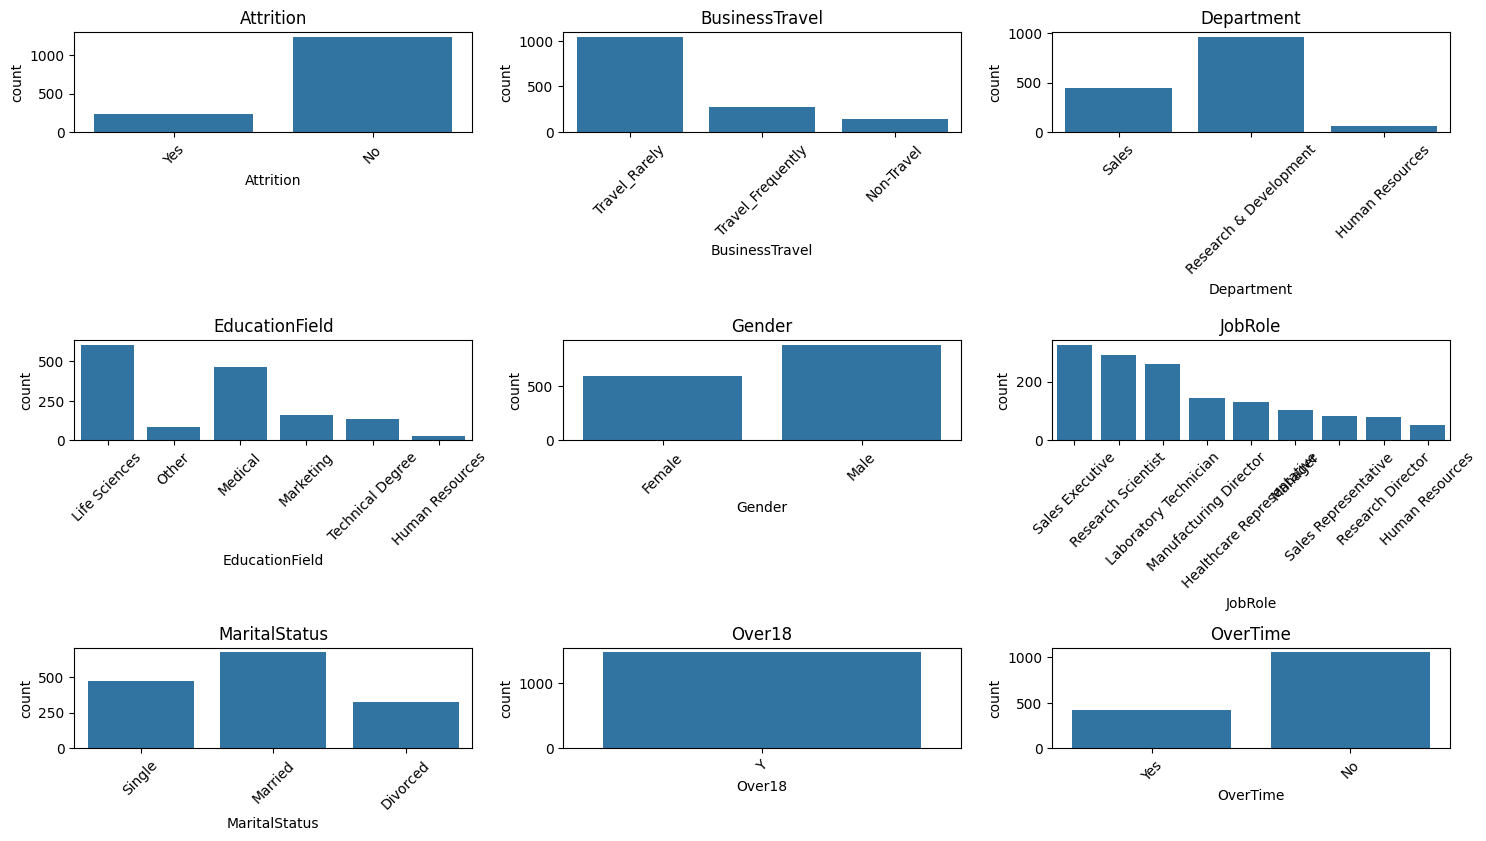

In [ ]:
# Distribution of categorical features (Countplot)
cat_cols = df.select_dtypes(include=['object']).columns

plt.figure(figsize=(15, 20))

for i, col in enumerate(cat_cols, 1):
    plt.subplot(7, 3, i)
    sns.countplot(x=df[col])
    plt.title(col)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

2. Bivariate Analysis

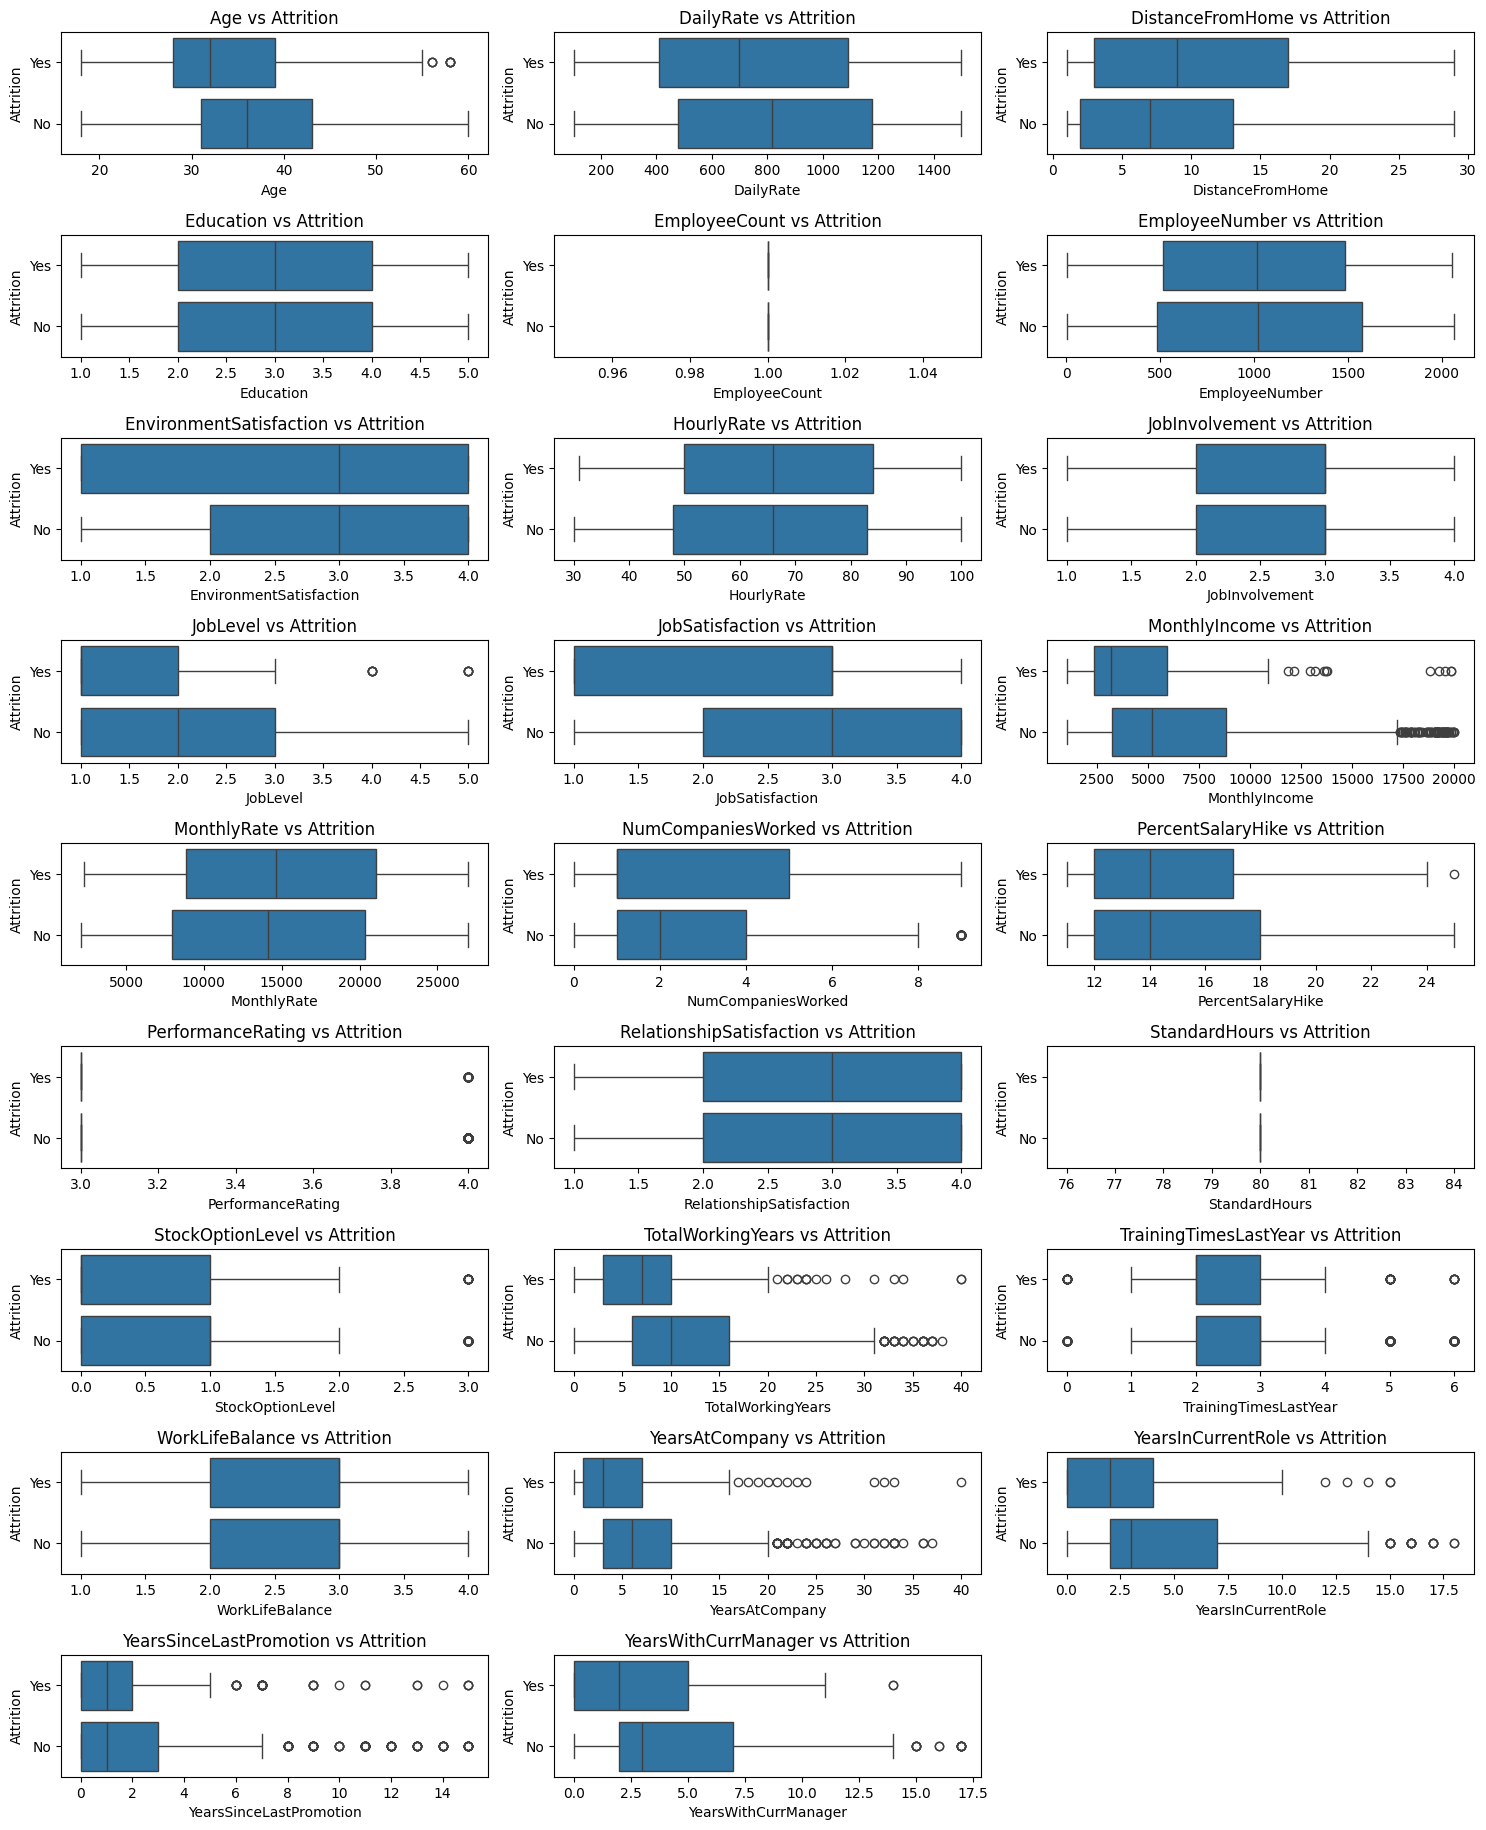

In [ ]:
# Attrition vs numerical features
plt.figure(figsize=(15, 20))

for i, col in enumerate(num_cols, 1):
    plt.subplot(10, 3, i)
    sns.boxplot(x=col, y='Attrition', data=df)
    plt.title(f"{col} vs Attrition")

plt.tight_layout()
plt.show()

**Insights:** The columns like Age, JobLevel, MonthlyIncome, NumCompaniesWorked, PercentSalaryHike, StockOptionLevel, TotalWorkingYears, TrainingTimesLastYear, YearsAtCompany, YearsInCurrentRole, YearsSinceLastPromotion, YearsWithCurrManager are having **Outliers** <br>
But we will not consider JobLevel and StockOptionLevel because those 2 columns are having ordinal data types.

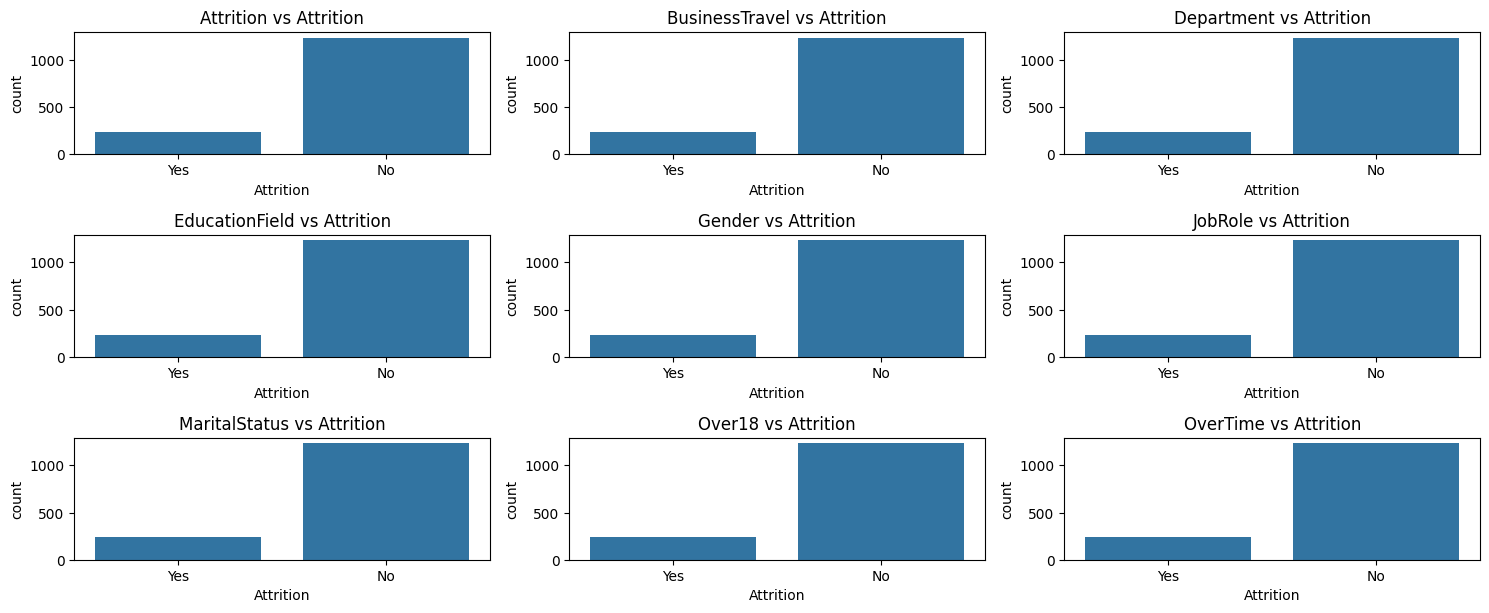

In [ ]:
# Attrition vs categorical features
plt.figure(figsize=(15, 20))

for i, col in enumerate(cat_cols, 1):
    plt.subplot(10, 3, i)
    sns.countplot(x='Attrition', data=df)
    plt.title(f"{col} vs Attrition")

plt.tight_layout()
plt.show()

3. Multivariate Analysis

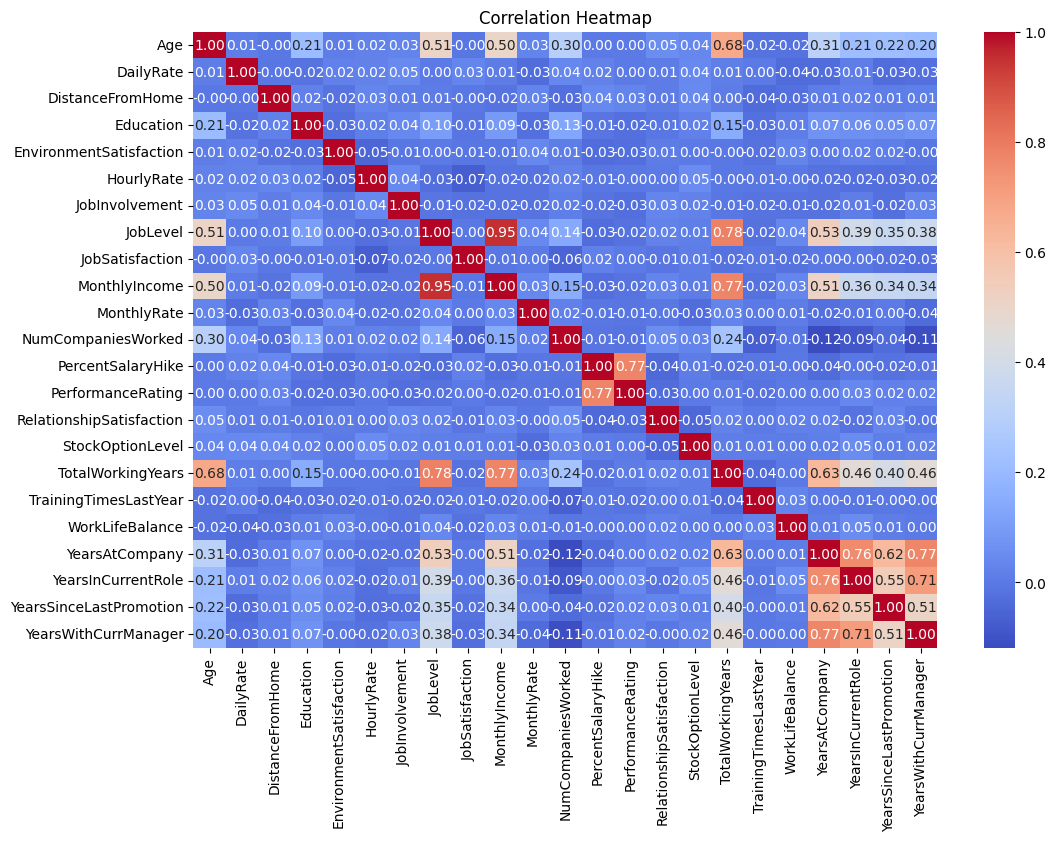

In [ ]:
# correlation heatmap

# drop useless columns
df.drop(['EmployeeCount','EmployeeNumber','Over18','StandardHours'], axis=1, inplace=True)

# Select only numerical columns
num_df = df.select_dtypes(include=['int64','float64'])

# Correlation matrix
corr = num_df.corr()

# Plot heatmap
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

### Dectect and handle the outliers

In [ ]:
#check for data distribution of columns having outliers
data = ['Age', 'MonthlyIncome', 'NumCompaniesWorked', 'PercentSalaryHike', 'TotalWorkingYears',
      'TrainingTimesLastYear', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']
for x in data:
  print(x,'-->',df[x].skew())
  print()

Age --> 0.4132863018563338

MonthlyIncome --> 1.3698166808390662

NumCompaniesWorked --> 1.026471111968205

PercentSalaryHike --> 0.8211279755780908

TotalWorkingYears --> 1.1171718528128527

TrainingTimesLastYear --> 0.5531241710537028

YearsAtCompany --> 1.7645294543422085

YearsInCurrentRole --> 0.9173631562908262

YearsSinceLastPromotion --> 1.9842899833524859

YearsWithCurrManager --> 0.8334509919918475



**Insights:**
* Age and TrainingTimesLastYear are having normal distribution so use 3-sigma rule
* For rest use IQR Technique as they are having skewed distribution
* Also JobLevel and StockOptionLevel are ordinal data type column so remove them

In [ ]:
# claculate % of outliers
outlier_percent = {}

for col in ['Age','MonthlyIncome','NumCompaniesWorked',
            'PercentSalaryHike','TotalWorkingYears',
            'TrainingTimesLastYear','YearsAtCompany','YearsInCurrentRole',
            'YearsSinceLastPromotion','YearsWithCurrManager']:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    percent = (len(outliers) / len(df)) * 100
    outlier_percent[col] = percent

# Display
for col, pct in outlier_percent.items():
    print(f"{col}: {pct:.2f}%")

Age: 0.00%
MonthlyIncome: 7.76%
NumCompaniesWorked: 3.54%
PercentSalaryHike: 0.00%
TotalWorkingYears: 4.29%
TrainingTimesLastYear: 16.19%
YearsAtCompany: 7.07%
YearsInCurrentRole: 1.43%
YearsSinceLastPromotion: 7.28%
YearsWithCurrManager: 0.95%


If % of outliers are less than 5% only then we will replace them with either mean or median based on thier data distribution type<br>
Handle outliers only in NumCompaniesWorked, TotalWorkingYears, YearsInCurrentRole, YearsWithCurrManager.

In [ ]:
# Handle the outliers if % of outliers is less than 5%
for col in outlier_percent:

    if outlier_percent[col] < 5:

        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        #  Calculate skewness
        skewness = df[col].skew()

        #  NORMAL distribution → MEAN
        if -0.5 < skewness < 0.5:
            value = df[col].mean()

        #  SKEWED → MEDIAN
        else:
            value = df[col].median()

        #  Replace outliers
        df[col] = df[col].apply(lambda x: value if x < lower or x > upper else x)

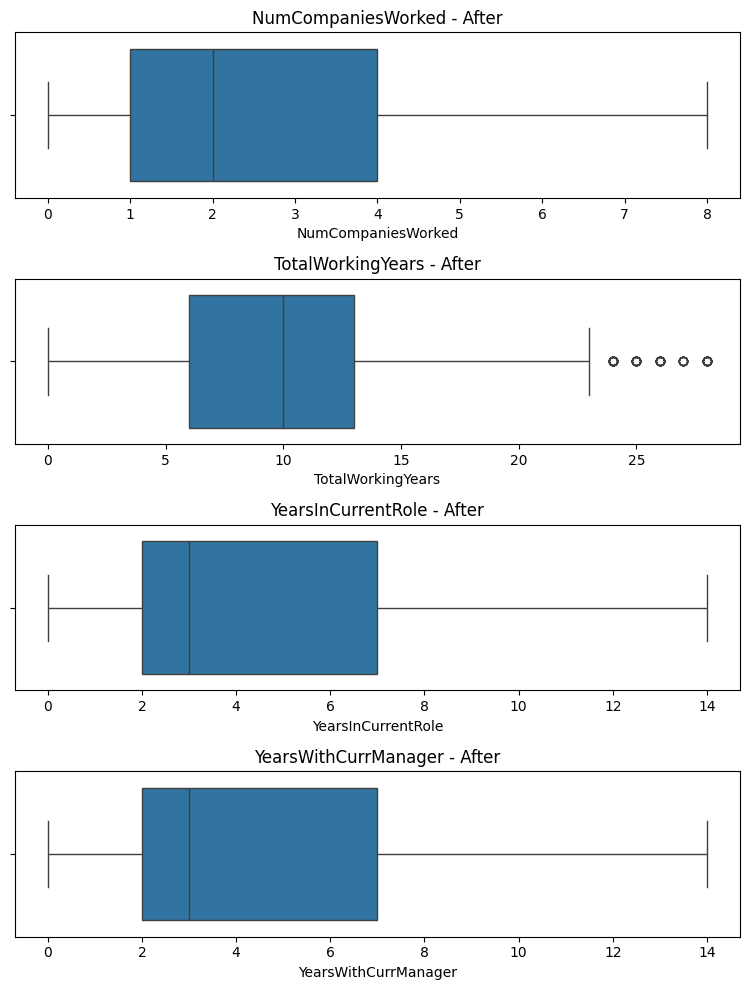

In [ ]:
#verification
cols = ['NumCompaniesWorked', 'TotalWorkingYears', 'YearsInCurrentRole', 'YearsWithCurrManager']

plt.figure(figsize=(15,10))

for i, col in enumerate(cols, 1):
    plt.subplot(4, 2, 2*i)
    sns.boxplot(x=df[col])
    plt.title(f"{col} - After")

plt.tight_layout()
plt.show()

Note: TotalWorkingYears is right-skewed so High experience values (25–30 yrs) are valid, not errors. Hence boxplot marks them as outliers.

### **Encoding**

In [ ]:
# Attrition and OverTime has values like yes or no so we will use label encoder
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Attrition'] = le.fit_transform(df['Attrition'])
df['OverTime'] = le.fit_transform(df['OverTime'])
df.dtypes

,0
Age,int64
Attrition,int64
BusinessTravel,object
DailyRate,int64
Department,object
DistanceFromHome,int64
Education,int64
EducationField,object
EnvironmentSatisfaction,int64
Gender,object


In [ ]:
# Gender
df['Gender'] = df['Gender'].map({'Male':1, 'Female':0})
df.dtypes

,0
Age,int64
Attrition,int64
BusinessTravel,object
DailyRate,int64
Department,object
DistanceFromHome,int64
Education,int64
EducationField,object
EnvironmentSatisfaction,int64
Gender,int64


In [ ]:
# one-hot encoding
df = pd.get_dummies(df, columns=['Department','JobRole','MaritalStatus','BusinessTravel','EducationField'], drop_first=True)

In [ ]:
df.dtypes

,0
Age,int64
Attrition,int64
DailyRate,int64
DistanceFromHome,int64
Education,int64
EnvironmentSatisfaction,int64
Gender,int64
HourlyRate,int64
JobInvolvement,int64
JobLevel,int64


### **Feature Engineering**

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('Attrition', axis=1)
y = df['Attrition']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### **Scaling**

In [ ]:
scale_cols = [
    'Age',
    'MonthlyIncome',
    'DistanceFromHome',
    'NumCompaniesWorked',
    'TotalWorkingYears',
    'TrainingTimesLastYear',
    'YearsAtCompany',
    'YearsInCurrentRole',
    'YearsSinceLastPromotion',
    'YearsWithCurrManager'
]

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test[scale_cols] = scaler.transform(X_test[scale_cols])

### **Balancing Data**

In [ ]:
print(y_train.value_counts())

Attrition
0    978
1    198
Name: count, dtype: int64


In [ ]:
# Apply SMOTE only on training data
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

In [ ]:
# verify balancing
print(y_train_sm.value_counts())

Attrition
0    978
1    978
Name: count, dtype: int64


### **Model Training: Classification Models**

In [ ]:
# Import models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
# Initialize Models
lr = LogisticRegression(max_iter=1000)
dt = DecisionTreeClassifier(random_state=42)
rf = RandomForestClassifier(random_state=42)
knn = KNeighborsClassifier()

In [ ]:
# Train Models
lr.fit(X_train_sm, y_train_sm)
dt.fit(X_train_sm, y_train_sm)
rf.fit(X_train_sm, y_train_sm)
knn.fit(X_train_sm, y_train_sm)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


KNeighborsClassifier()

In [ ]:
# Predictions
y_pred_lr = lr.predict(X_test)
y_pred_dt = dt.predict(X_test)
y_pred_rf = rf.predict(X_test)
y_pred_knn = knn.predict(X_test)

### **Model Evaluation**

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

print("Logistic Regression:", accuracy_score(y_test, y_pred_lr))
print("Decision Tree:", accuracy_score(y_test, y_pred_dt))
print("Random Forest:", accuracy_score(y_test, y_pred_rf))
print("KNN:", accuracy_score(y_test, y_pred_knn))

Logistic Regression: 0.8333333333333334
Decision Tree: 0.7210884353741497
Random Forest: 0.8707482993197279
KNN: 0.5952380952380952


### **Improving Model Performance**

Further improvising model performances by
* choosing best k value for knn model,
* applying gini index for decision tree model,
* applying hyperparameters for random forest model

[np.float64(0.1598639455782313), np.float64(0.20068027210884354), np.float64(0.1564625850340136), np.float64(0.17687074829931973), np.float64(0.14285714285714285), np.float64(0.14625850340136054), np.float64(0.13945578231292516), np.float64(0.14285714285714285), np.float64(0.13945578231292516)]


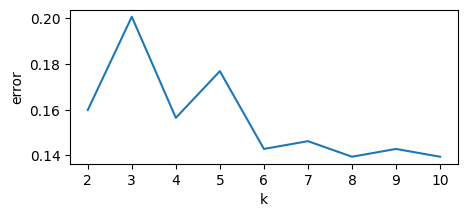

In [ ]:
# how to choose best k
error_rate = []
for k in range(2,11):
  model = KNeighborsClassifier(n_neighbors=k)
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  error_rate.append(np.mean(y_test!=y_pred))
print(error_rate)

plt.figure(figsize=(5,2))
plt.plot(range(2,11),error_rate)
plt.xlabel('k')
plt.ylabel('error')
plt.show()

In [ ]:
# use k = 8
knn_improved = KNeighborsClassifier(n_neighbors=8)
knn_improved.fit(X_train_sm, y_train_sm)
y_pred_knn_improved = knn_improved.predict(X_test)
print("KNN after improving:", accuracy_score(y_test, y_pred_knn_improved))
print("KNN before improving:", accuracy_score(y_test, y_pred_knn))

KNN after improving: 0.6326530612244898
KNN before improving: 0.5952380952380952


In [ ]:
# using gini inndex
dt_improved = DecisionTreeClassifier(random_state=42, criterion='gini',
                               max_depth=10,max_features='sqrt',
                               splitter='best',min_samples_leaf=3,
                               min_samples_split=5)
dt_improved.fit(X_train_sm, y_train_sm)
y_pred_dt_improved = dt_improved.predict(X_test)
print("Decision Tree after improving:", accuracy_score(y_test, y_pred_dt_improved))
print("Decision Tree before improving:", accuracy_score(y_test, y_pred_dt))

Decision Tree after improving: 0.7721088435374149
Decision Tree before improving: 0.7210884353741497


In [ ]:
# hyperparameters
rf_improved = RandomForestClassifier(random_state=42, n_estimators=10, min_samples_split=5,
                                     min_samples_leaf=6, max_depth=50,max_features='sqrt',
                                     bootstrap=True, criterion='gini')
rf_improved.fit(X_train_sm, y_train_sm)
y_pred_rf_improved = rf_improved.predict(X_test)
print("Random Forest after improving:", accuracy_score(y_test, y_pred_rf_improved))
print("Random Forest before improving:", accuracy_score(y_test, y_pred_rf))

Random Forest after improving: 0.8605442176870748
Random Forest before improving: 0.8707482993197279


### Model Evaluation with other metrices

In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix

# Store predictions in a dictionary
models = {
    "Logistic Regression": y_pred_lr,
    "Decision Tree": y_pred_dt_improved,
    "Random Forest": y_pred_rf_improved,
    "KNN": y_pred_knn_improved
}

# Create empty dictionary for results
results = {
    "Accuracy": [],
    "Recall": [],
    "Precision": [],
    "F1 Score": [],
    "Confusion Matrix": []
}

# Calculate metrics
for model, y_pred in models.items():
    results["Accuracy"].append(accuracy_score(y_test, y_pred))
    results["Recall"].append(recall_score(y_test, y_pred))
    results["Precision"].append(precision_score(y_test, y_pred))
    results["F1 Score"].append(f1_score(y_test, y_pred))
    results["Confusion Matrix"].append(confusion_matrix(y_test, y_pred))

# Convert to DataFrame
df = pd.DataFrame(results, index=models.keys()).T

print(df)

                    Logistic Regression          Decision Tree  \
Accuracy                       0.833333               0.772109   
Recall                         0.461538               0.307692   
Precision                      0.391304               0.230769   
F1 Score                       0.423529               0.263736   
Confusion Matrix  [[227, 28], [21, 18]]  [[215, 40], [27, 12]]   

                          Random Forest                    KNN  
Accuracy                       0.860544               0.632653  
Recall                         0.384615               0.410256  
Precision                       0.46875               0.158416  
F1 Score                       0.422535               0.228571  
Confusion Matrix  [[238, 17], [24, 15]]  [[170, 85], [23, 16]]  


**ROC-AUC Score and Curve**

LR AUC: 0.7850175967823027
DT AUC: 0.6401206636500754
RF AUC: 0.7460532931121167
KNN AUC: 0.5645047762694821


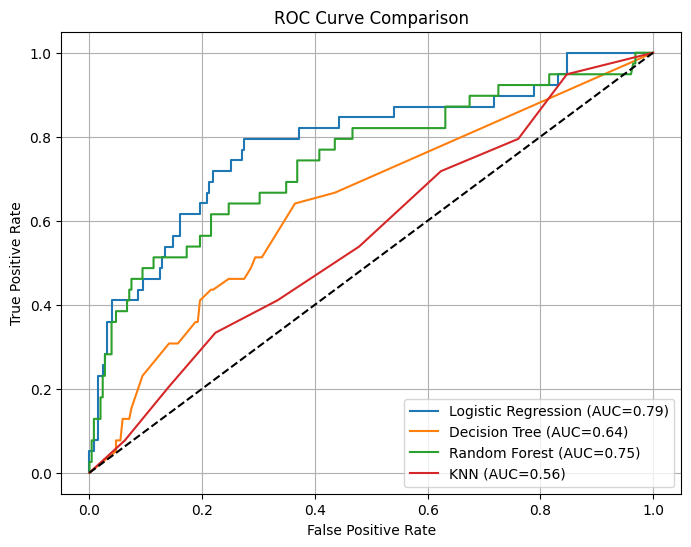

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

#Get probability scores
y_prob_lr = lr.predict_proba(X_test)[:,1]
y_prob_dt = dt_improved.predict_proba(X_test)[:,1]
y_prob_rf = rf_improved.predict_proba(X_test)[:,1]
y_prob_knn = knn_improved.predict_proba(X_test)[:,1]

#Calculate ROC-AUC score
print("LR AUC:", roc_auc_score(y_test, y_prob_lr))
print("DT AUC:", roc_auc_score(y_test, y_prob_dt))
print("RF AUC:", roc_auc_score(y_test, y_prob_rf))
print("KNN AUC:", roc_auc_score(y_test, y_prob_knn))

#ROC Curve points
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn)

#Plot ALL curves together
plt.figure(figsize=(8,6))

plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC={roc_auc_score(y_test, y_prob_lr):.2f})")
plt.plot(fpr_dt, tpr_dt, label=f"Decision Tree (AUC={roc_auc_score(y_test, y_prob_dt):.2f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC={roc_auc_score(y_test, y_prob_rf):.2f})")
plt.plot(fpr_knn, tpr_knn, label=f"KNN (AUC={roc_auc_score(y_test, y_prob_knn):.2f})")

plt.plot([0,1],[0,1],'k--')  # baseline

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend(loc="lower right")
plt.grid()

plt.show()

**Insights:**
* Logistic Regression has the highest AUC-ROC score of 0.79 and then Random Forest has strong AUC-ROC score of 0.75
* Hence Logistic Regression and Random Forest are the best models

### **K Fold Cross Validation**

In [ ]:
from sklearn.model_selection import KFold , cross_val_score
from xgboost import XGBClassifier

model = XGBClassifier()
kf = KFold(n_splits=5,shuffle=True,random_state=42)
scores = cross_val_score(model,X_train_sm,y_train_sm,cv=kf)
print(scores)
print(np.mean(scores))

[0.91836735 0.93094629 0.90537084 0.93094629 0.9258312 ]
0.9222923952189571


### **Stratified Cross Validation**

In [ ]:
from sklearn.model_selection import StratifiedKFold
model = XGBClassifier()
sf = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
scores = cross_val_score(model,X_train_sm,y_train_sm,cv=sf)
print(scores)
print(np.mean(scores))

[0.92602041 0.9028133  0.91560102 0.91815857 0.93861893]
0.9202424448040085


### **Comparing Model Performance**

In [ ]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

models = {
    "Logistic Regression": y_pred_lr,
    "Decision Tree": y_pred_dt_improved,
    "Random Forest": y_pred_rf_improved,
    "KNN": y_pred_knn_improved
}

best_model = None
best_score = 0

for model, y_pred in models.items():
    acc = accuracy_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    avg_score = (acc + rec + prec + f1) / 4   # combined score

    print(f"{model}: Avg Score = {avg_score:.4f}")

    if avg_score > best_score:
        best_score = avg_score
        best_model = model

print("\nBest Model:", best_model)
print("Best Overall Score:", best_score)

Logistic Regression: Avg Score = 0.5274
Decision Tree: Avg Score = 0.3936
Random Forest: Avg Score = 0.5341
KNN: Avg Score = 0.3575

Best Model: Random Forest
Best Overall Score: 0.5341112033925163


### **Best Model**

According to the above shown scores, Random Forest is the best model.

### **Final Insights**

<h3>Key Factors Influencing Attrition</h3>

<ol>
  <li>
    <strong>OverTime</strong>
    <ul>
      <li>Employees working overtime → much higher attrition</li>
      <li>Biggest driver</li>
    </ul>
  </li>

  <li>
    <strong>MonthlyIncome</strong>
    <ul>
      <li>Lower salary → higher attrition</li>
      <li>Higher income → better retention</li>
    </ul>
  </li>

  <li>
    <strong>JobSatisfaction</strong>
    <ul>
      <li>Low satisfaction → high attrition</li>
      <li>Satisfied employees tend to stay</li>
    </ul>
  </li>

  <li>
    <strong>WorkLifeBalance</strong>
    <ul>
      <li>Poor balance → employees leave</li>
      <li>Good balance → improves retention</li>
    </ul>
  </li>

  <li>
    <strong>YearsAtCompany</strong>
    <ul>
      <li>Employees leave mostly in early years</li>
      <li>Longer tenure → lower attrition</li>
    </ul>
  </li>

### **Business Recommendations**

<h3>Business Recommendations</h3>

<ol>
  <li>
    <strong>Reduce Overtime Workload</strong>
    <ul>
      <li>Limit excessive overtime to avoid employee burnout</li>
      <li>Introduce flexible work schedules</li>
    </ul>
  </li>

  <li>
    <strong>Improve Compensation Structure</strong>
    <ul>
      <li>Offer competitive salaries to retain employees</li>
      <li>Provide performance-based incentives</li>
    </ul>
  </li>

  <li>
    <strong>Enhance Job Satisfaction</strong>
    <ul>
      <li>Conduct regular feedback surveys</li>
      <li>Recognize and reward employee contributions</li>
    </ul>
  </li>